# Nuclei segmentation + transduction efficiency (streamlined)

Two-part pipeline, run top-to-bottom:

- **Part 1** looks at every channel, lets you pick which one to segment on, then segments nuclei in 3D with Cellpose-SAM (`cpsam_v2`) after optional binning and Gaussian denoising. The reporter channel is *not* touched in this part.
- **Part 2** picks the reporter channel and computes transduction efficiency with a shell-overlap protocol: each nucleus is dilated into a thin peri-nuclear shell, the reporter channel is thresholded, and a nucleus is called transduced if enough of its shell is reporter-positive.

Every code cell is preceded by a short markdown note on what it does and why. All configuration lives in the cell that uses it, and every filtering/thresholding step is followed by a small plot so the result can be checked before moving on.

# Part 1 — Nuclei segmentation

**Configuration.** Paths, acquisition geometry, and the expected nucleus size — everything needed before we've even looked at the image. Channel assignment happens later, once the channels can be seen.

In [ ]:
import os
import numpy as np
import tifffile
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import czifile
from scipy import ndimage
from czifile import imread

# =========================================================
# CONFIGURATION -- edit everything here, nothing below
# =========================================================
input_folder = r"\\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\RxGFP\2026\RxGFP_r26a_p24\experiments\LSM\20260325_DIV37_VLP"                                                                    # <-- folder containing the image
image_filename = r"20260325_RxGFP_DIV37_VLP233mScarlet2percent_Nucspot650-02.czi"      # <-- image file name

image_path = os.path.join(input_folder, image_filename)

# --- voxel geometry (from acquisition) ---
with czifile.CziFile(image_path) as czi:
    items = czi.metadata(asdict=True)["ImageDocument"]["Metadata"]["Scaling"]["Items"]["Distance"]
    for item in items:
        print(item)
        if item["Id"] == "X" or item["Id"] == "Y":
            xy_pixel_um = item["Value"] * 10e5
        if item["Id"] == "Z":
            z_step_um = item["Value"] * 10e5

print("Scaling xy:", xy_pixel_um, "Scaling z:", z_step_um)

# --- expected cell size ---
expected_cell_diameter_um = 4.0        # <-- adjust to your cell type

# --- Cellpose ---
model_type = "cpsam_v2"                # newest Cellpose-SAM model
use_gpu = True

# --- labels for outputs ---
condition_label = "VLP233 mScarlet10%"
cell_line = "RxGFP"

output_dir = os.path.dirname(os.path.abspath(image_path)) or "."
base_name = os.path.splitext(os.path.basename(image_path))[0]

print(f"Voxel size: {xy_pixel_um} x {xy_pixel_um} x {z_step_um} um")
print(f"Output folder: {output_dir}")

Voxel size: 0.2072 x 0.2072 x 50 um
Output folder: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\RxGFP\2026\RxGFP_r26a_p24\experiments\LSM\20260325_DIV37_VLP


**Load the raw image.** Reads the full multi-channel z-stack from disk.

In [28]:
img = imread(image_path)
print("Loaded shape:", img.shape)
print("dtype:", img.dtype)
print("Size in RAM: %.2f GB" % (img.nbytes / 1e9))
print("ndim:", img.ndim)

Loaded shape: (3, 101, 1024, 1024)
dtype: uint8
Size in RAM: 0.32 GB
ndim: 4


**Look at every channel.** Mid-plane view of each channel in the stack, assuming a `(Z, C, Y, X)` layout — used to pick the segmentation channel by eye in the next cell.

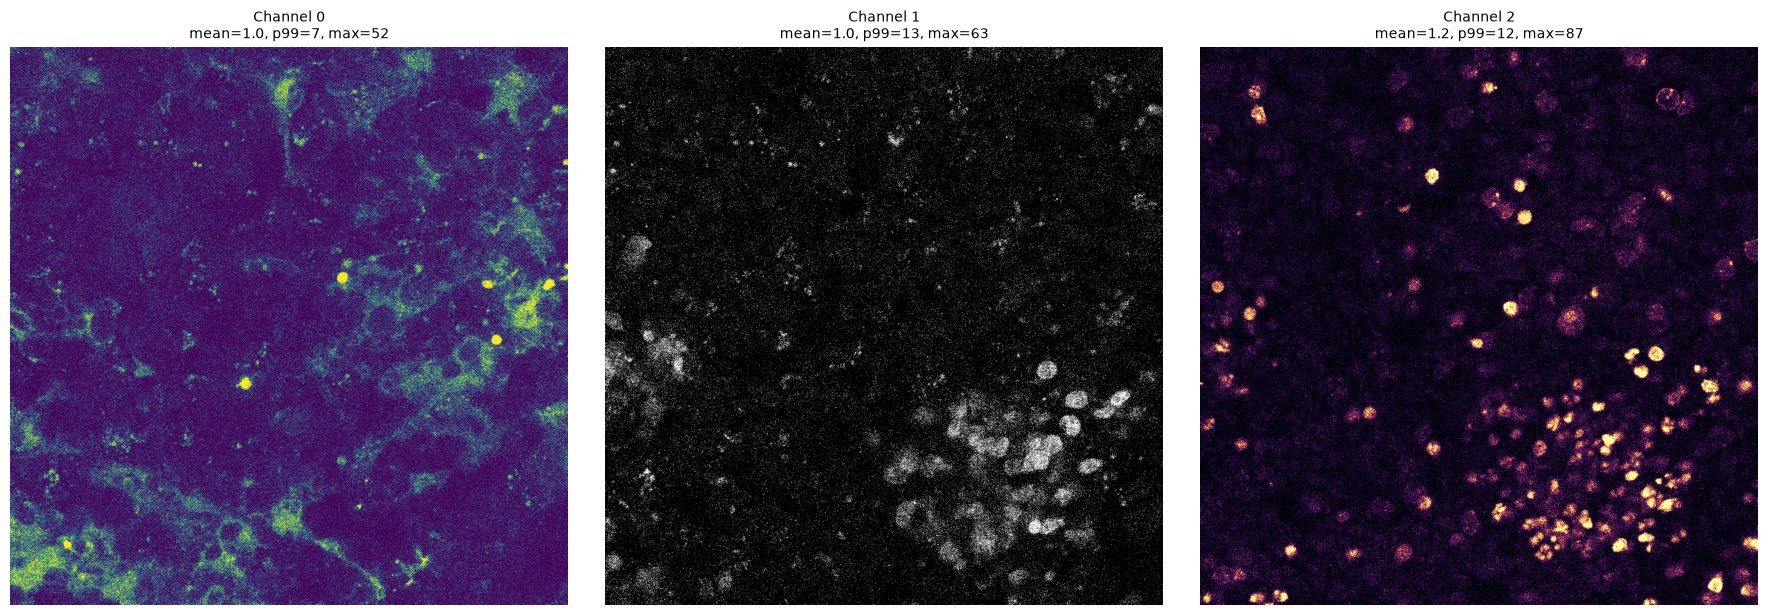

In [29]:
# =========================================================
# Assumes (Z, C, Y, X). If your data is (C, Z, Y, X) instead,
# swap the indexing below to img[c, mid_z].
# =========================================================
n_channels = img.shape[0]
mid_z = img.shape[1] // 2

fig, axes = plt.subplots(1, n_channels, figsize=(6 * n_channels, 6))
if n_channels == 1:
    axes = [axes]

cmaps = ["viridis", "gray", "inferno"]

for c in range(n_channels):
    plane = img[c, mid_z]
    axes[c].imshow(plane, cmap=cmaps[c],
                   vmin=np.percentile(plane, 1), vmax=np.percentile(plane, 99))
    axes[c].set_title(f"Channel {c}\nmean={plane.mean():.1f}, p99={np.percentile(plane, 99):.0f}, max={plane.max():.0f}",
                       fontsize=10)
    axes[c].axis("off")

plt.tight_layout()
plt.show()

**Pick the segmentation channel.** Set this to whichever channel above shows clean nuclear structure (e.g. a nuclear stain). This is the only channel used for segmentation — the reporter channel isn't selected until Part 2.

In [30]:
segmentation_channel = 2   # <-- set from the channel plot above (e.g. NucSpot650)
print(f"Segmentation channel: {segmentation_channel}")

Segmentation channel: 2


**Extract the segmentation channel.** Reduces to a single `(Z, Y, X)` volume for Cellpose. The reporter channel isn't extracted here — it's only needed in Part 2.

In [9]:
# =========================================================
# Reduce to (Z, Y, X). UNCOMMENT the block matching your shape
# (see the channel plot above).
# =========================================================

# --- if (Z, C, Y, X) ---
# seg_stack = img[:, segmentation_channel]

# --- if (C, Z, Y, X) ---
seg_stack = img[segmentation_channel]

assert seg_stack.ndim >= 3, f"seg_stack must be (Z, Y, X), got {seg_stack.shape}"

n_z, n_y, n_x = seg_stack.shape
print(f"Segmentation stack: {seg_stack.shape} (Z, Y, X)")
print(f"Physical volume: {n_x*xy_pixel_um:.0f} x {n_y*xy_pixel_um:.0f} x {n_z*z_step_um:.0f} um")

Segmentation stack: (101, 1024, 1024) (Z, Y, X)
Physical volume: 212 x 212 x 5050 um


**Preprocessing: binning + denoising.** Python equivalents of the arivis Binning and Denoise steps, applied to the segmentation channel before Cellpose. `bin_percent = 1.0` disables binning; `denoise_sigma_px = 0` disables denoising. The effective pixel size computed here is reused everywhere downstream, in both parts.

Binning factor: 1x (bin_percent=1.0)
  (101, 1024, 1024) -> (101, 1024, 1024)
Gaussian denoising: sigma = 1.0 µm (xy only)...
Effective xy pixel size: 0.2072 um | anisotropy: 2.41


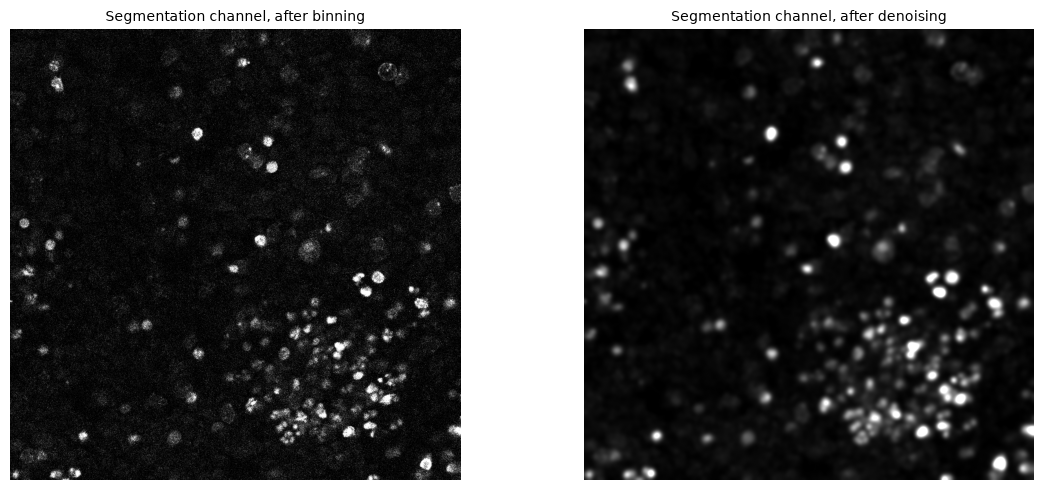

In [31]:
# =========================================================
# PREPROCESSING -- binning + denoising
# -----------------------------------------------------------------
# bin_percent = 1.0 means no binning; e.g. 0.5 bins 2x2 in xy (z is
# never binned -- it's already coarsely sampled and binning it would
# merge adjacent nuclei). denoise_sigma_px = 0 disables denoising.
# =========================================================
bin_percent = 1.0
denoise_sigma_um = 1.0

bin_factor = max(1, round(1 / bin_percent))


def bin_xy(stack, factor):
    if factor == 1:
        return stack
    z, y, x = stack.shape
    y_crop, x_crop = (y // factor) * factor, (x // factor) * factor
    if (y_crop, x_crop) != (y, x):
        print(f"  cropping {y}x{x} -> {y_crop}x{x_crop} to divide evenly by {factor}")
        stack = stack[:, :y_crop, :x_crop]
    return stack.reshape(z, y_crop // factor, factor,
                         x_crop // factor, factor).mean(axis=(2, 4))


print(f"Binning factor: {bin_factor}x (bin_percent={bin_percent})")
seg_binned = bin_xy(seg_stack.astype(np.float32), bin_factor)
print(f"  {seg_stack.shape} -> {seg_binned.shape}")

# effective voxel geometry after binning -- used everywhere below,
# in both Part 1 and Part 2
xy_pixel_um_eff = xy_pixel_um * bin_factor
anisotropy_eff = z_step_um / xy_pixel_um_eff
voxel_volume_um3 = xy_pixel_um_eff * xy_pixel_um_eff * z_step_um

if denoise_sigma_um > 0:
    print(f"Gaussian denoising: sigma = {denoise_sigma_um} µm (xy only)...")
    denoise_sigma_px = denoise_sigma_um / xy_pixel_um_eff
    seg_processed = ndimage.gaussian_filter(seg_binned, sigma=(0, denoise_sigma_px, denoise_sigma_px))
else:
    seg_processed = seg_binned

print(f"Effective xy pixel size: {xy_pixel_um_eff:.4f} um | anisotropy: {anisotropy_eff:.2f}")

# --- before/after comparison ---
mid = seg_processed.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title in [(axes[0], seg_binned[mid], "Segmentation channel, after binning"),
                        (axes[1], seg_processed[mid], "Segmentation channel, after denoising")]:
    ax.imshow(data, cmap="gray", vmin=np.percentile(data, 1), vmax=np.percentile(data, 99.5))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Load the Cellpose-SAM model.** Newest Cellpose-SAM model, loaded directly — no legacy API fallback.

In [32]:
from cellpose import models
import torch

model = models.CellposeModel(gpu=use_gpu, model_type=model_type)

print(f"Cellpose model: {model_type}")
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name())

c:\Users\Thor\anaconda3\envs\cellpose\Lib\site-packages\torch\cuda\__init__.py:422: UserWarning: Found GPU1 NVIDIA GeForce GT 1030 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Your installed torch==2.13.0+cu130 does not include kernels for this GPU. Reinstall the same version against a CUDA build that does, e.g.:
  For CUDA 12.6 use pip install torch==2.13.0 --index-url https://download.pytorch.org/whl/cu126
  _warn_unsupported_code(d, device_cc, code_ccs)
c:\Users\Thor\anaconda3\envs\cellpose\Lib\site-packages\torch\cuda\__init__.py:540: UserWarning: 
NVIDIA GeForce GT 1030 with C

Cellpose model: cpsam_v2
CUDA available: True
GPU: NVIDIA RTX A4000


**Segment nuclei in true 3D.** A single `do_3D=True` call over the whole processed volume — no 2D-per-slice + stitching fallback.

In [33]:
# =========================================================
# TRUE 3D SEGMENTATION
# -----------------------------------------------------------------
# z_axis and anisotropy are required with do_3D -- Cellpose will not
# guess them. anisotropy_eff accounts for any binning applied above.
# This call is deliberately NOT wrapped in try/except, so any real
# error surfaces with its full traceback instead of being masked.
# =========================================================
eval_kwargs = dict(
    channels=[0, 0],
    z_axis=0,
    channel_axis=None,
    anisotropy=anisotropy_eff,
    do_3D=True,
)

print(f"Running true 3D segmentation on {seg_processed.shape}...")
masks_3d, flows, styles = model.eval(seg_processed, **eval_kwargs)

n_objects = int(masks_3d.max())
print(f"\nFound {n_objects} 3D objects.")

if n_objects == 0:
    raise ValueError(
        "0 objects detected. Check the segmentation channel and preprocessing plots above."
    )

seg_path = os.path.join(output_dir, f"{base_name}_seg3d.npy")
np.save(seg_path, masks_3d)
print(f"Saved masks to: {seg_path}")

Running true 3D segmentation on (101, 1024, 1024)...


c:\Users\Thor\anaconda3\envs\cellpose\Lib\site-packages\cellpose\dynamics.py:541: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\Context.cpp:823.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),



Found 1575 3D objects.
Saved masks to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\RxGFP\2026\RxGFP_r26a_p24\experiments\LSM\20260325_DIV37_VLP\20260325_RxGFP_DIV37_VLP233mScarlet2percent_Nucspot650-02_seg3d.npy


**Filter by volume.** Drops fragments/debris below a floor set from the expected nucleus size (20% of the expected sphere volume). No upper bound — oversized objects are rare merges, left in rather than guessing a fixed ceiling.

Objects before filtering: 20
Volume filter: >= 7 um^3 (expected cell ~34 um^3)
Objects after filtering:  7


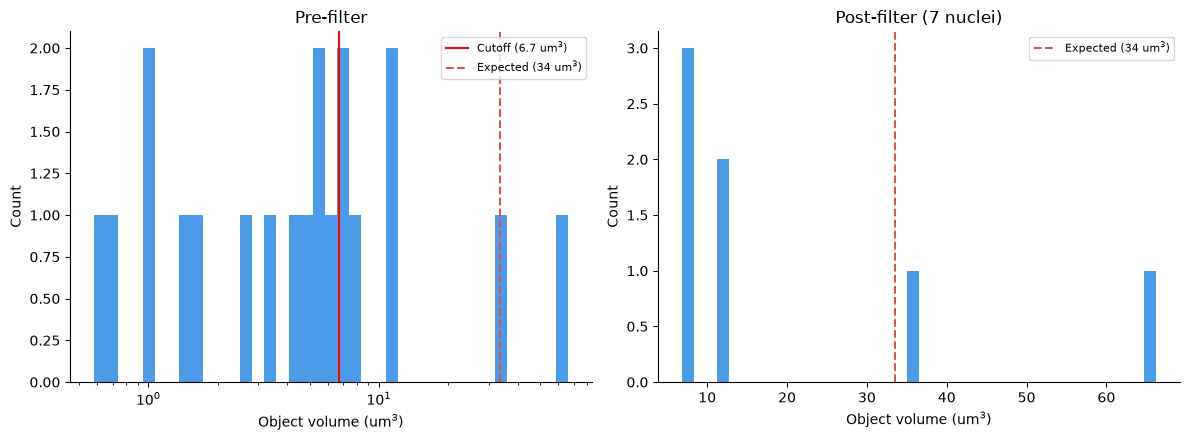

Saved filtered masks: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_nuclei_seg3d_filtered.npy


In [ ]:
labels = np.unique(masks_3d)
labels = labels[labels != 0]

voxel_counts = ndimage.sum(np.ones_like(masks_3d), labels=masks_3d, index=labels)
volumes_um3 = voxel_counts * voxel_volume_um3

expected_vol = (4/3) * np.pi * (expected_cell_diameter_um / 2) ** 3
min_volume_um3 = 0.2 * expected_vol

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bins_log = np.logspace(np.log10(volumes_um3.min()), np.log10(volumes_um3.max()), 40)
axes[0].hist(volumes_um3, bins=bins_log, color="#4C9BE8", edgecolor="none")
axes[0].axvline(min_volume_um3, color="red", label=f"Cutoff ({min_volume_um3:.1f} um$^3$)")
axes[0].axvline(expected_vol, color="#D9534F", linestyle="--", label=f"Expected ({expected_vol:.0f} um$^3$)")
axes[0].set_xlabel("Object volume (um$^3$)"); axes[0].set_ylabel("Count")
axes[0].set_title("Pre-filter"); axes[0].set_xscale("log")
axes[0].legend(fontsize=8); axes[0].spines[["top", "right"]].set_visible(False)

keep = volumes_um3 >= min_volume_um3
print(f"Objects before filtering: {len(labels)}")
print(f"Volume filter: >= {min_volume_um3:.0f} um^3 (expected cell ~{expected_vol:.0f} um^3)")
print(f"Objects after filtering:  {keep.sum()}")

labels = labels[keep]
volumes_um3 = volumes_um3[keep]

if len(labels) == 0:
    raise ValueError("All objects removed by the volume filter -- check expected_cell_diameter_um "
                      "or the segmentation channel above.")

axes[1].hist(volumes_um3, bins=40, color="#4C9BE8", edgecolor="none")
axes[1].axvline(expected_vol, color="#D9534F", linestyle="--", label=f"Expected ({expected_vol:.0f} um$^3$)")
axes[1].set_xlabel("Object volume (um$^3$)"); axes[1].set_ylabel("Count")
axes[1].set_title(f"Post-filter ({len(labels)} nuclei)")
axes[1].legend(fontsize=8); axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

masks_filtered = np.where(np.isin(masks_3d, labels), masks_3d, 0)
filt_path = os.path.join(output_dir, f"{base_name}_nuclei_seg3d_filtered.npy")
np.save(filt_path, masks_filtered)
print(f"Saved filtered masks: {filt_path}")

**Per-nucleus measurements.** Centroids, volumes and mean intensity for every retained nucleus, saved to CSV, with a segmentation overlay to check quality.

Nuclei segmented : 7
Median volume    : 11.9 um^3
Saved CSV        : \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_nuclei_measurements.csv


C:\Users\Thor\AppData\Local\Temp\3\ipykernel_17224\1076572294.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved SVG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_nuclei_segmentation.svg
Saved PNG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_nuclei_segmentation.png


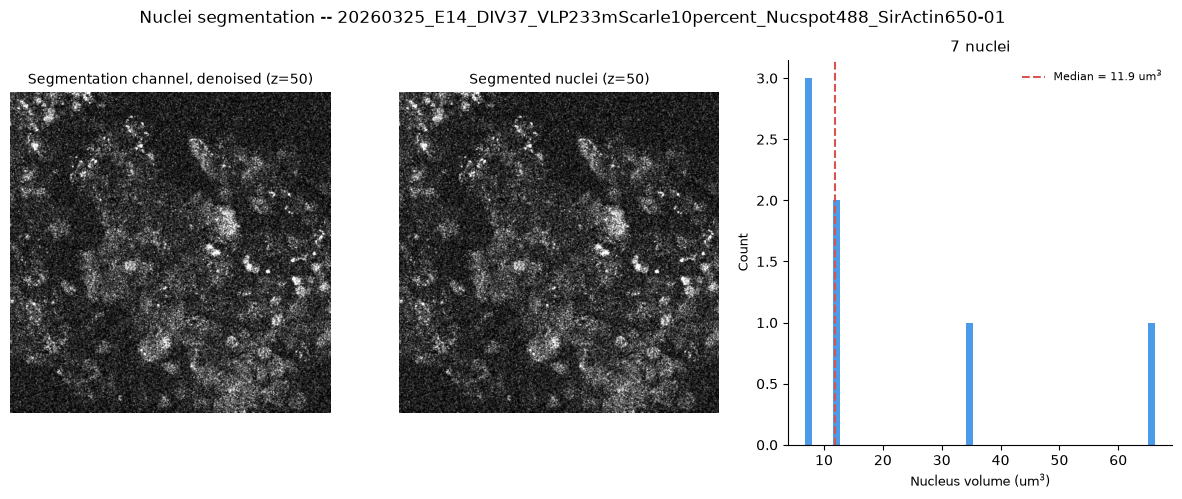

In [ ]:
centroids = np.array(ndimage.center_of_mass(masks_filtered > 0, labels=masks_filtered, index=labels))

nuclei_df = pd.DataFrame({
    "label": labels.astype(int),
    "volume_um3": volumes_um3,
    "centroid_z_um": centroids[:, 0] * z_step_um,
    "centroid_y_um": centroids[:, 1] * xy_pixel_um_eff,
    "centroid_x_um": centroids[:, 2] * xy_pixel_um_eff,
    "mean_intensity": ndimage.mean(seg_processed, labels=masks_filtered, index=labels),
})

csv_path = os.path.join(output_dir, f"{base_name}_nuclei_measurements.csv")
nuclei_df.to_csv(csv_path, index=False)

print(f"Nuclei segmented : {len(nuclei_df)}")
print(f"Median volume    : {nuclei_df['volume_um3'].median():.1f} um^3")
print(f"Saved CSV        : {csv_path}")

mid = seg_processed.shape[0] // 2
fig = plt.figure(figsize=(15, 5), facecolor="white")
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.2)

ax = fig.add_subplot(gs[0])
ax.imshow(seg_processed[mid], cmap="gray",
          vmin=np.percentile(seg_processed[mid], 1), vmax=np.percentile(seg_processed[mid], 99.5))
ax.set_title(f"Segmentation channel, denoised (z={mid})", fontsize=10); ax.axis("off")

ax = fig.add_subplot(gs[1])
ax.imshow(seg_processed[mid], cmap="gray",
          vmin=np.percentile(seg_processed[mid], 1), vmax=np.percentile(seg_processed[mid], 99.5))
plane = masks_filtered[mid]
if plane.max() > 0:
    ax.contour(plane, levels=np.arange(0.5, plane.max() + 0.5), colors="#4C9BE8", linewidths=0.5)
ax.set_title(f"Segmented nuclei (z={mid})", fontsize=10); ax.axis("off")

ax = fig.add_subplot(gs[2])
ax.hist(nuclei_df["volume_um3"], bins=50, color="#4C9BE8", edgecolor="none")
ax.axvline(nuclei_df["volume_um3"].median(), color="#D9534F", linestyle="--",
           label=f"Median = {nuclei_df['volume_um3'].median():.1f} um$^3$")
ax.set_xlabel("Nucleus volume (um$^3$)", fontsize=9); ax.set_ylabel("Count", fontsize=9)
ax.set_title(f"{len(nuclei_df)} nuclei", fontsize=11)
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Nuclei segmentation -- {base_name}", fontsize=12)
plt.tight_layout()

svg_path = os.path.join(output_dir, f"{base_name}_nuclei_segmentation.svg")
png_path = os.path.join(output_dir, f"{base_name}_nuclei_segmentation.png")
fig.savefig(svg_path, format="svg", facecolor="white", bbox_inches="tight")
fig.savefig(png_path, format="png", dpi=300, facecolor="white", bbox_inches="tight")
print(f"Saved SVG: {svg_path}")
print(f"Saved PNG: {png_path}")
plt.show()

**Sanity check: 3D view of the segmentation.** Orthogonal slices and a 3D centroid scatter, to catch obvious segmentation problems (missed regions, merged nuclei, edge effects) before moving on to transduction analysis.

C:\Users\Thor\AppData\Local\Temp\3\ipykernel_17224\2948524817.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PNG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_3d_visualisation.png
Saved SVG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_3d_visualisation.svg


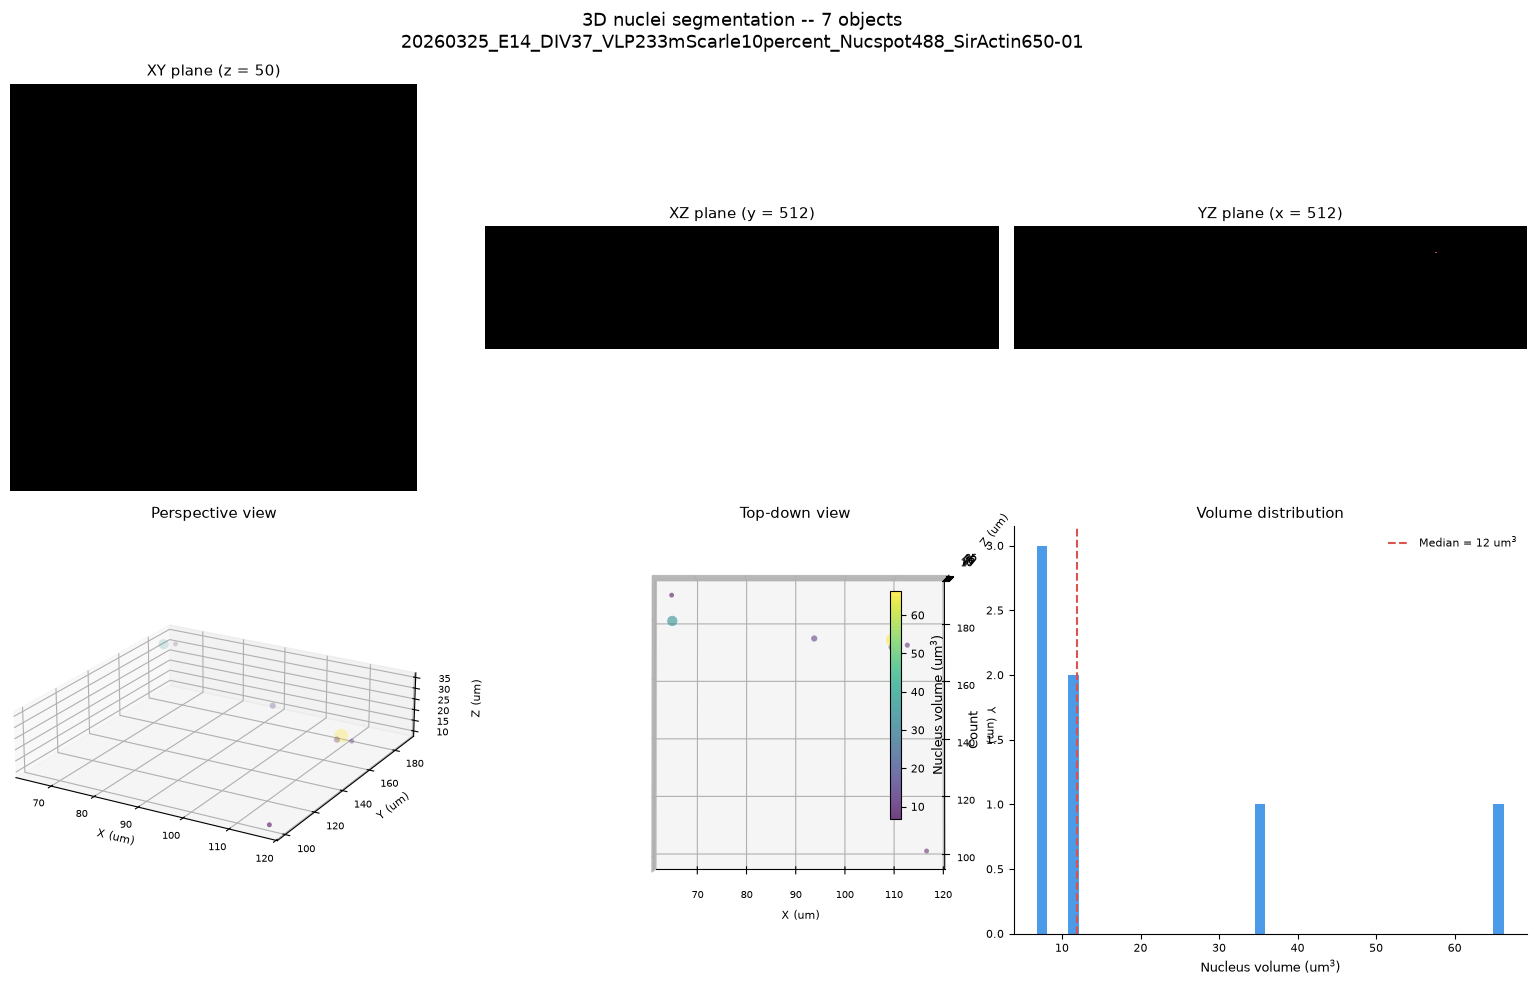


napari viewer opened -- drag to rotate, scroll to zoom.
Run napari.run() if the window does not appear.


In [ ]:
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

nz, ny, nx = masks_filtered.shape
mid_z2, mid_y, mid_x = nz // 2, ny // 2, nx // 2
aspect = z_step_um / xy_pixel_um_eff

rng = np.random.default_rng(42)
colors = rng.random((int(masks_filtered.max()) + 1, 3)) * 0.75 + 0.25
colors[0] = [0, 0, 0]                       # background black
label_cmap = ListedColormap(colors)

fig = plt.figure(figsize=(16, 10), facecolor="white")

for i, (data, title, asp) in enumerate([
    (masks_filtered[mid_z2],       f"XY plane (z = {mid_z2})", 1),
    (masks_filtered[:, mid_y, :],  f"XZ plane (y = {mid_y})", aspect),
    (masks_filtered[:, :, mid_x],  f"YZ plane (x = {mid_x})", aspect),
]):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.imshow(data, cmap=label_cmap, interpolation="nearest", aspect=asp)
    ax.set_title(title, fontsize=11)
    ax.axis("off")

cx_um = nuclei_df["centroid_x_um"].values
cy_um = nuclei_df["centroid_y_um"].values
cz_um = nuclei_df["centroid_z_um"].values
vol = nuclei_df["volume_um3"].values
sizes = 12 + 90 * (vol - vol.min()) / (np.ptp(vol) + 1e-9)

for j, (elev, azim, view_title) in enumerate([(22, -60, "Perspective view"),
                                               (89, -90, "Top-down view")]):
    ax = fig.add_subplot(2, 3, 4 + j, projection="3d")
    p = ax.scatter(cx_um, cy_um, cz_um, c=vol, s=sizes,
                   cmap="viridis", alpha=0.75, edgecolors="none")
    ax.set_xlabel("X (um)", fontsize=8)
    ax.set_ylabel("Y (um)", fontsize=8)
    ax.set_zlabel("Z (um)", fontsize=8)
    ax.set_title(view_title, fontsize=11)
    ax.tick_params(labelsize=7)
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((nx * xy_pixel_um_eff, ny * xy_pixel_um_eff, nz * z_step_um))

cbar = fig.colorbar(p, ax=fig.axes[4:6], shrink=0.65, pad=0.02)
cbar.set_label("Nucleus volume (um$^3$)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax = fig.add_subplot(2, 3, 6)
ax.hist(vol, bins=45, color="#4C9BE8", edgecolor="none")
ax.axvline(np.median(vol), color="#D9534F", linestyle="--", linewidth=1.5,
           label=f"Median = {np.median(vol):.0f} um$^3$")
ax.set_xlabel("Nucleus volume (um$^3$)", fontsize=9)
ax.set_ylabel("Count", fontsize=9)
ax.set_title("Volume distribution", fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=8)

fig.suptitle(f"3D nuclei segmentation -- {len(nuclei_df)} objects\n{base_name}", fontsize=13)
plt.tight_layout()

png_path = os.path.join(output_dir, f"{base_name}_3d_visualisation.png")
svg_path = os.path.join(output_dir, f"{base_name}_3d_visualisation.svg")
fig.savefig(png_path, format="png", dpi=250, facecolor="white", bbox_inches="tight")
fig.savefig(svg_path, format="svg", facecolor="white", bbox_inches="tight")
print(f"Saved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")
plt.show()

# =========================================================
# OPTIONAL -- interactive rotatable 3D view
# Requires napari: pip install "napari[all]". Skipped silently if
# not installed.
# =========================================================
# try:
#     import napari

#     viewer = napari.Viewer(ndisplay=3)
#     viewer.add_labels(
#         masks_filtered,
#         name="nuclei",
#         scale=(z_step_um, xy_pixel_um_eff, xy_pixel_um_eff),
#     )
#     print("\nnapari viewer opened -- drag to rotate, scroll to zoom.")
#     print("Run napari.run() if the window does not appear.")
# except ImportError:
#     print("\nnapari not installed -- skipping interactive view.")
#     print('Install with: pip install "napari[all]"')

# Part 2 — Transduction efficiency (shell-overlap protocol)

Uses `masks_filtered`, `nuclei_df`, `bin_factor`, `voxel_volume_um3`, `xy_pixel_um_eff` and `z_step_um` from Part 1 — run Part 1 first.

This part first picks and preprocesses the reporter channel (not needed until now), then classifies each nucleus as transduced or not: each nucleus is dilated into a thin peri-nuclear shell, the reporter channel is thresholded, and a nucleus is called transduced if enough of its shell is reporter-positive. Step numbers in the comments below refer to the underlying protocol.

**Select and preprocess the reporter channel.** Pick the reporter channel from the channel plot at the start of Part 1, then apply the same binning + denoising used for the segmentation channel so the two stay in registration.

Reporter channel: 0
  (101, 1024, 1024) -> (101, 1024, 1024)


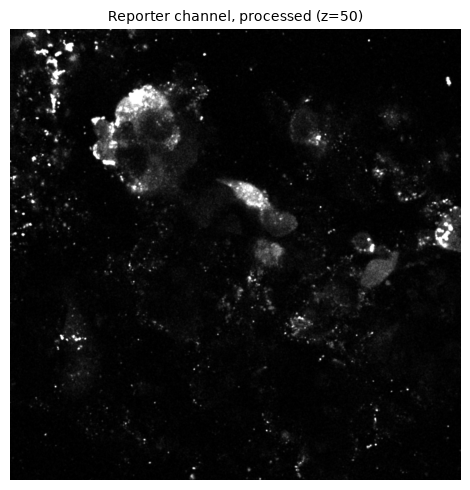

In [ ]:
reporter_channel = 0   # <-- set from the channel plot at the start of Part 1

# --- if (Z, C, Y, X) ---
rep_stack = img[:, reporter_channel]

# --- if (C, Z, Y, X) ---
# rep_stack = img[reporter_channel]

assert rep_stack.shape == seg_stack.shape, "Reporter and segmentation stacks must match in shape"

rep_binned = bin_xy(rep_stack.astype(np.float32), bin_factor)
if denoise_sigma_px > 0:
    rep_processed = ndimage.gaussian_filter(rep_binned, sigma=(0, denoise_sigma_px, denoise_sigma_px))
else:
    rep_processed = rep_binned

print(f"Reporter channel: {reporter_channel}")
print(f"  {rep_stack.shape} -> {rep_processed.shape}")

mid = rep_processed.shape[0] // 2
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(rep_processed[mid], cmap="gray",
          vmin=np.percentile(rep_processed[mid], 1), vmax=np.percentile(rep_processed[mid], 99.5))
ax.set_title(f"Reporter channel, processed (z={mid})", fontsize=10)
ax.axis("off")
plt.tight_layout(); plt.show()

**Shell-overlap protocol configuration.** All thresholds for the rest of Part 2, in one place.

In [ ]:
from skimage.morphology import binary_dilation, ball

# =========================================================
# SHELL-OVERLAP PROTOCOL -- CONFIGURATION
# =========================================================
REPORTER_INTENSITY_THRESHOLD = 10.0   # step 1.2 -- set by eye from the histogram below, re-run
TRANSDUCED_MIN_VOL_UM3       = 10.0   # step 1.3 -- transduced objects > 10 um^3
NUCLEI_MIN_VOL_UM3           = 1.0  # step 2.1 -- nuclei > 100 um^3
DILATION_PIXELS              = 5      # step 2.2 -- shell dilation
SHELL_MIN_VOL_UM3            = 30.0   # step 2.4 -- 30 um^3 for mouse tissue
OVERLAP_THRESHOLD            = 0.40   # step 2.5/2.6 -- overlap >= 40%

print("=== SHELL-OVERLAP PARAMETERS ===")
print(f"Reporter intensity threshold : >= {REPORTER_INTENSITY_THRESHOLD}")
print(f"Transduced object min volume : {TRANSDUCED_MIN_VOL_UM3} um^3")
print(f"Nuclei min volume            : {NUCLEI_MIN_VOL_UM3} um^3")
print(f"Dilation                     : {DILATION_PIXELS} px")
print(f"Shell min volume             : {SHELL_MIN_VOL_UM3} um^3")
print(f"Overlap threshold            : {OVERLAP_THRESHOLD:.0%}")

=== SHELL-OVERLAP PARAMETERS ===
Reporter intensity threshold : >= 10.0
Transduced object min volume : 10.0 um^3
Nuclei min volume            : 1.0 um^3
Dilation                     : 5 px
Shell min volume             : 30.0 um^3
Overlap threshold            : 40%


**Reporter-positive voxels (step 1).** Threshold the reporter channel by intensity, then drop small specks below a minimum object size. `rep_processed` is already binned + denoised — no second smoothing pass here, so the two parts stay in registration.

=== REPORTER INTENSITY DISTRIBUTION ===
  p50    =     0.40
  p75    =     0.67
  p90    =     1.45
  p95    =     2.78
  p99    =    11.31
  p99.9  =    43.98
  max    =   248.50

Threshold set to: 10.0
Voxels above threshold: 1,233,175 (1.16% of volume)

Transduced objects before size filter: 6017
After >10.0 um^3 filter        : 148


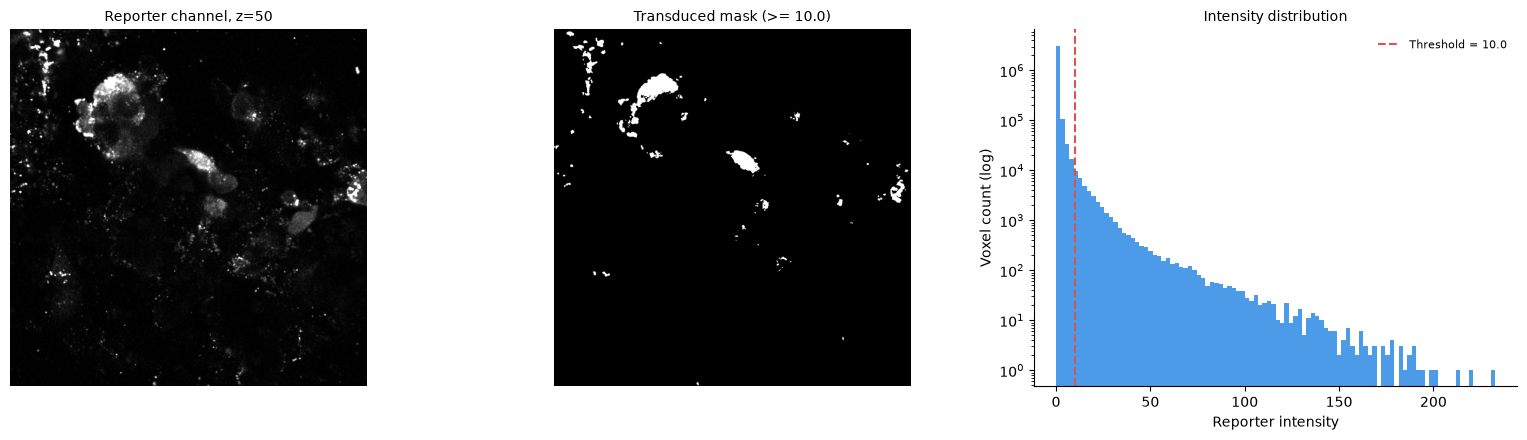

In [ ]:
# =========================================================
# STEP 1 -- REPORTER-POSITIVE VOXELS
# =========================================================
print("=== REPORTER INTENSITY DISTRIBUTION ===")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  p{p:<5} = {np.percentile(rep_processed, p):8.2f}")
print(f"  max    = {rep_processed.max():8.2f}")
print(f"\nThreshold set to: {REPORTER_INTENSITY_THRESHOLD}")

transduced_raw = rep_processed >= REPORTER_INTENSITY_THRESHOLD
pct_above = 100 * transduced_raw.mean()
print(f"Voxels above threshold: {transduced_raw.sum():,} ({pct_above:.2f}% of volume)")

if pct_above > 60:
    print("WARNING: >60% of the volume is above threshold -- likely too low.")
elif pct_above < 0.1:
    print("WARNING: <0.1% of the volume is above threshold -- likely too high.")

# --- step 1.3: keep only objects > TRANSDUCED_MIN_VOL_UM3 ---
lbl, n_obj = ndimage.label(transduced_raw)
sizes = ndimage.sum(np.ones_like(lbl), labels=lbl, index=np.arange(1, n_obj + 1))
vols = sizes * voxel_volume_um3
keep_ids = np.arange(1, n_obj + 1)[vols >= TRANSDUCED_MIN_VOL_UM3]
transduced_mask = np.isin(lbl, keep_ids)

print(f"\nTransduced objects before size filter: {n_obj}")
print(f"After >{TRANSDUCED_MIN_VOL_UM3} um^3 filter        : {len(keep_ids)}")

mid = rep_processed.shape[0] // 2
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

d = rep_processed[mid]
axes[0].imshow(d, cmap="gray", vmin=np.percentile(d, 1), vmax=np.percentile(d, 99.5))
axes[0].set_title(f"Reporter channel, z={mid}", fontsize=10); axes[0].axis("off")

axes[1].imshow(transduced_mask[mid].astype(np.uint8), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Transduced mask (>= {REPORTER_INTENSITY_THRESHOLD})", fontsize=10)
axes[1].axis("off")

ax = axes[2]
sample = rep_processed[::2, ::4, ::4].ravel()      # subsample for speed
ax.hist(sample, bins=100, color="#4C9BE8", edgecolor="none", log=True)
ax.axvline(REPORTER_INTENSITY_THRESHOLD, color="#D9534F", linestyle="--", linewidth=1.5,
           label=f"Threshold = {REPORTER_INTENSITY_THRESHOLD}")
ax.set_xlabel("Reporter intensity"); ax.set_ylabel("Voxel count (log)")
ax.set_title("Intensity distribution", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(); plt.show()

**Filter nuclei by volume for the shell protocol (step 2.1).** A separate, coarser volume floor than Part 1's — this one governs which nuclei get a shell built at all.

Nuclei before size filter : 7
Threshold                 : >= 1.0 um^3
Nuclei after size filter  : 7
Median volume             : 11.9 um^3


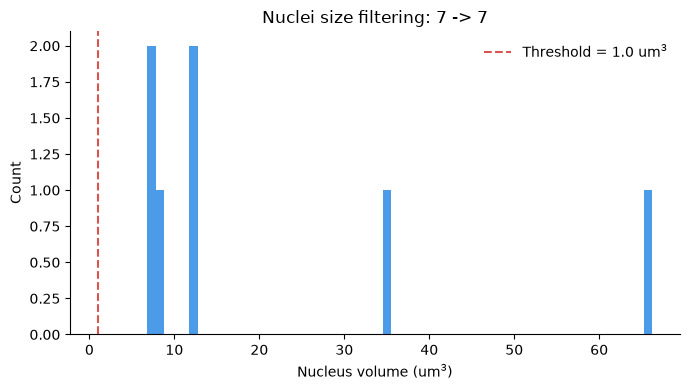

In [ ]:
# =========================================================
# STEP 2.1 -- NUCLEUS SIZE FILTER
# =========================================================
nuc_labels = np.unique(masks_filtered)
nuc_labels = nuc_labels[nuc_labels != 0]

nuc_voxels = ndimage.sum(np.ones_like(masks_filtered), labels=masks_filtered, index=nuc_labels)
nuc_volumes = nuc_voxels * voxel_volume_um3

keep_nuc = nuc_volumes >= NUCLEI_MIN_VOL_UM3
nuclei_kept = nuc_labels[keep_nuc]
nuclei_volumes_kept = nuc_volumes[keep_nuc]

print(f"Nuclei before size filter : {len(nuc_labels)}")
print(f"Threshold                 : >= {NUCLEI_MIN_VOL_UM3} um^3")
print(f"Nuclei after size filter  : {len(nuclei_kept)}")

if len(nuclei_kept) == 0:
    raise ValueError(f"No nuclei above {NUCLEI_MIN_VOL_UM3} um^3 -- lower NUCLEI_MIN_VOL_UM3.")

print(f"Median volume             : {np.median(nuclei_volumes_kept):.1f} um^3")

nuclei_size_filtered = np.where(np.isin(masks_filtered, nuclei_kept), masks_filtered, 0)

plt.figure(figsize=(7, 4))
plt.hist(nuc_volumes, bins=60, color="#4C9BE8", edgecolor="none")
plt.axvline(NUCLEI_MIN_VOL_UM3, color="#D9534F", linestyle="--",
            label=f"Threshold = {NUCLEI_MIN_VOL_UM3} um$^3$")
plt.xlabel("Nucleus volume (um$^3$)"); plt.ylabel("Count")
plt.title(f"Nuclei size filtering: {len(nuc_labels)} -> {len(nuclei_kept)}")
plt.legend(frameon=False); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Build peri-nuclear shells (step 2.2).** Dilate each nucleus individually and subtract its own volume, so every shell voxel belongs unambiguously to exactly one nucleus. Includes a close-up sanity check on one example nucleus.

Building shells for 7 nuclei (dilation = 5 px)...


C:\Users\Thor\AppData\Local\Temp\3\ipykernel_17224\2925834183.py:29: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  dilated = binary_dilation(sub, struct)


  7/7
Shells created. Total shell voxels: 46,736


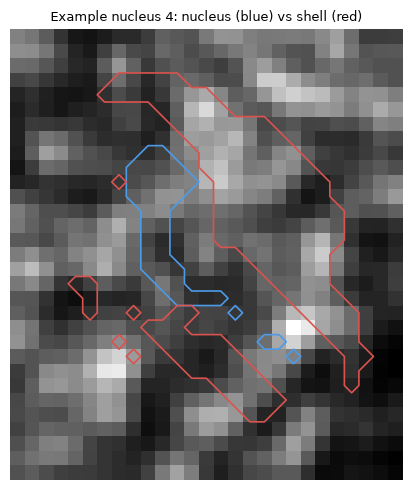

In [ ]:
# =========================================================
# STEP 2.2 -- BUILD PERI-NUCLEAR SHELLS
# -----------------------------------------------------------------
# Each nucleus is dilated individually and its own volume subtracted
# (A - B), so shell k belongs unambiguously to nucleus k. Dilating
# the whole label image at once would let neighbouring nuclei bleed
# into each other's shells. Each nucleus is processed on a small,
# padded bounding-box crop -- dilating the full volume per nucleus
# would be prohibitively slow.
# =========================================================
struct = ball(DILATION_PIXELS)
shells = np.zeros_like(nuclei_size_filtered, dtype=np.int32)

print(f"Building shells for {len(nuclei_kept)} nuclei (dilation = {DILATION_PIXELS} px)...")

for i, lab in enumerate(nuclei_kept):
    nuc_bin = (nuclei_size_filtered == lab)

    coords = np.argwhere(nuc_bin)
    zmin, ymin, xmin = coords.min(axis=0)
    zmax, ymax, xmax = coords.max(axis=0) + 1
    pad = DILATION_PIXELS + 1
    zmin, ymin, xmin = max(0, zmin - pad), max(0, ymin - pad), max(0, xmin - pad)
    zmax = min(nuc_bin.shape[0], zmax + pad)
    ymax = min(nuc_bin.shape[1], ymax + pad)
    xmax = min(nuc_bin.shape[2], xmax + pad)

    sub = nuc_bin[zmin:zmax, ymin:ymax, xmin:xmax]
    dilated = binary_dilation(sub, struct)
    shell_sub = dilated & ~sub                      # A - B

    region = shells[zmin:zmax, ymin:ymax, xmin:xmax]
    region[shell_sub & (region == 0)] = lab          # don't overwrite existing shells

    if (i + 1) % 100 == 0 or i == len(nuclei_kept) - 1:
        print(f"  {i+1}/{len(nuclei_kept)}", end="\r")

print(f"\nShells created. Total shell voxels: {(shells>0).sum():,}")

np.save(os.path.join(output_dir, f"{base_name}_shells.npy"), shells)

# --- sanity check: nucleus vs. its shell, cropped around one example ---
# (bounding box via np.argwhere, not ndimage.find_objects -- find_objects
# needs an integer label array and rejects a boolean mask)
mid_lab = nuclei_kept[len(nuclei_kept) // 2]
coords = np.argwhere(nuclei_size_filtered == mid_lab)
zmin, ymin, xmin = coords.min(axis=0)
zmax, ymax, xmax = coords.max(axis=0) + 1
pad = DILATION_PIXELS + 2
zmin, ymin, xmin = max(0, zmin - pad), max(0, ymin - pad), max(0, xmin - pad)
zmax = min(nuclei_size_filtered.shape[0], zmax + pad)
ymax = min(nuclei_size_filtered.shape[1], ymax + pad)
xmax = min(nuclei_size_filtered.shape[2], xmax + pad)
z_mid = (zmin + zmax) // 2

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(seg_processed[z_mid, ymin:ymax, xmin:xmax], cmap="gray")
ax.contour(nuclei_size_filtered[z_mid, ymin:ymax, xmin:xmax] == mid_lab, levels=[0.5],
           colors="#4C9BE8", linewidths=1.2)
ax.contour(shells[z_mid, ymin:ymax, xmin:xmax] == mid_lab, levels=[0.5],
           colors="#D9534F", linewidths=1.2)
ax.set_title(f"Example nucleus {mid_lab}: nucleus (blue) vs shell (red)", fontsize=9)
ax.axis("off")
plt.tight_layout(); plt.show()

**Filter shells by volume (step 2.4).** Also reports the nuclei:shell ratio as a consistency check — it should stay close to 1.0.

Shells before filter : 7
Threshold            : >= 30.0 um^3 (mouse tissue)
Shells after filter  : 7

Size-filtered nuclei : 7
Size-filtered shells : 7
Nuclei:shell ratio   : 1.000
Ratio close to 1.0 -- shell generation looks consistent.


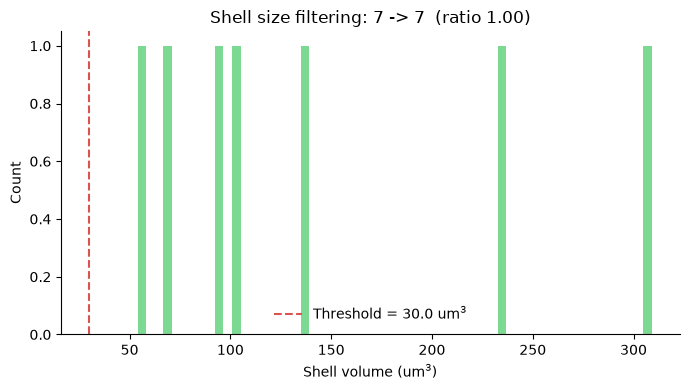

In [ ]:
# =========================================================
# STEP 2.4 -- SHELL SIZE FILTER
# =========================================================
shell_labels = np.unique(shells)
shell_labels = shell_labels[shell_labels != 0]

shell_voxels = ndimage.sum(np.ones_like(shells), labels=shells, index=shell_labels)
shell_volumes = shell_voxels * voxel_volume_um3

keep_shell = shell_volumes >= SHELL_MIN_VOL_UM3
shells_kept = shell_labels[keep_shell]
shell_volumes_kept = shell_volumes[keep_shell]

shells_filtered = np.where(np.isin(shells, shells_kept), shells, 0)

n_nuclei = len(nuclei_kept)
n_shells = len(shells_kept)
ratio = n_shells / n_nuclei if n_nuclei else float("nan")

print(f"Shells before filter : {len(shell_labels)}")
print(f"Threshold            : >= {SHELL_MIN_VOL_UM3} um^3 (mouse tissue)")
print(f"Shells after filter  : {n_shells}")
print(f"\nSize-filtered nuclei : {n_nuclei}")
print(f"Size-filtered shells : {n_shells}")
print(f"Nuclei:shell ratio   : {ratio:.3f}")

if abs(ratio - 1.0) > 0.15:
    print("\nWARNING: ratio deviates >15% from 1.0 -- consider adjusting SHELL_MIN_VOL_UM3, "
          "otherwise nuclei are being lost at the shell stage.")
else:
    print("Ratio close to 1.0 -- shell generation looks consistent.")

plt.figure(figsize=(7, 4))
plt.hist(shell_volumes, bins=60, color="#7CD992", edgecolor="none")
plt.axvline(SHELL_MIN_VOL_UM3, color="#D9534F", linestyle="--",
            label=f"Threshold = {SHELL_MIN_VOL_UM3} um$^3$")
plt.xlabel("Shell volume (um$^3$)"); plt.ylabel("Count")
plt.title(f"Shell size filtering: {len(shell_labels)} -> {n_shells}  (ratio {ratio:.2f})")
plt.legend(frameon=False); plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

**Call each nucleus transduced or not (steps 2.5/2.6).** A nucleus counts as transduced if enough of its shell overlaps the reporter-positive mask.

In [ ]:
# =========================================================
# STEP 2.5/2.6 -- OVERLAP + TRANSDUCTION CALL
# =========================================================
overlap_counts = ndimage.sum(transduced_mask.astype(np.float32),
                             labels=shells_filtered, index=shells_kept)
overlap_fraction = overlap_counts / (shell_volumes_kept / voxel_volume_um3)

shell_df = pd.DataFrame({
    "nucleus_label": shells_kept.astype(int),
    "shell_volume_um3": shell_volumes_kept,
    "nucleus_volume_um3": nuclei_volumes_kept[np.isin(nuclei_kept, shells_kept)],
    "overlap_voxels": overlap_counts,
    "overlap_fraction": overlap_fraction,
})
shell_df["transduced"] = shell_df["overlap_fraction"] >= OVERLAP_THRESHOLD

n_transduced = int(shell_df["transduced"].sum())
n_total = len(shell_df)
efficiency = 100 * n_transduced / n_total

print(f"Overlap threshold : {OVERLAP_THRESHOLD:.0%}")
print(f"Total nuclei      : {n_total}")
print(f"Transduced nuclei : {n_transduced}")
print(f"\nTRANSDUCTION EFFICIENCY: {efficiency:.2f}%")
print(f"\nOverlap distribution: median={shell_df['overlap_fraction'].median():.3f}, "
      f"mean={shell_df['overlap_fraction'].mean():.3f}")

Overlap threshold : 40%
Total nuclei      : 7
Transduced nuclei : 1

TRANSDUCTION EFFICIENCY: 14.29%

Overlap distribution: median=0.000, mean=0.132


**Threshold sensitivity.** How much does the efficiency number depend on the exact thresholds chosen? Flat regions = robust result; steep slopes = the number depends heavily on an arbitrary cutoff, which should be reported alongside the headline figure.

Scanning intensity thresholds (this takes a moment)...
  intensity   4.00 -> efficiency  14.3%
  intensity   6.29 -> efficiency  14.3%
  intensity   8.57 -> efficiency  14.3%
  intensity  10.86 -> efficiency  14.3%
  intensity  13.14 -> efficiency  14.3%
  intensity  15.43 -> efficiency  14.3%
  intensity  17.71 -> efficiency   0.0%
  intensity  20.00 -> efficiency   0.0%

Saved PNG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_threshold_sensitivity_int10_ov0.4.png
Saved SVG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_threshold_sensitivity_int10_ov0.4.svg


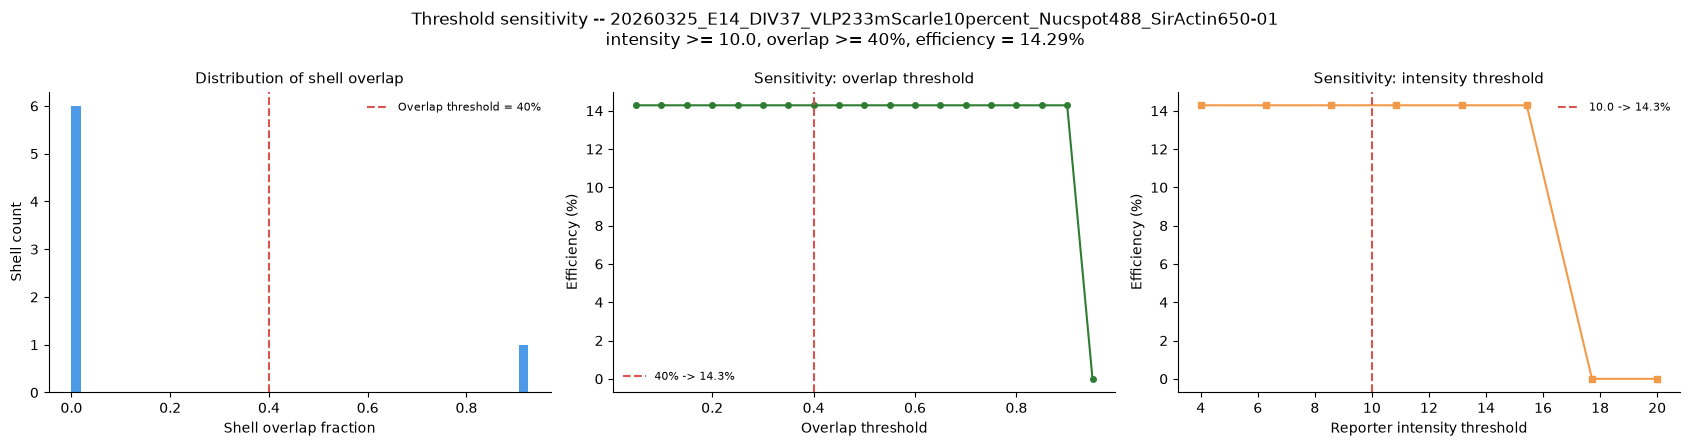

Saved CSV: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_threshold_sensitivity_int10_ov0.4.csv


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# --- overlap distribution ---
ax = axes[0]
ax.hist(shell_df["overlap_fraction"], bins=50, color="#4C9BE8", edgecolor="none")
ax.axvline(OVERLAP_THRESHOLD, color="#D9534F", linestyle="--", linewidth=1.5,
           label=f"Overlap threshold = {OVERLAP_THRESHOLD:.0%}")
ax.set_xlabel("Shell overlap fraction"); ax.set_ylabel("Shell count")
ax.set_title("Distribution of shell overlap", fontsize=11)
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)

# --- sensitivity to the OVERLAP threshold ---
ax = axes[1]
ov_thresh = np.arange(0.05, 1.0, 0.05)
ov_effs = [100 * (shell_df["overlap_fraction"] >= t).sum() / n_total for t in ov_thresh]
ax.plot(ov_thresh, ov_effs, marker="o", color="#2E7D32", markersize=4)
ax.axvline(OVERLAP_THRESHOLD, color="#D9534F", linestyle="--", linewidth=1.5,
           label=f"{OVERLAP_THRESHOLD:.0%} -> {efficiency:.1f}%")
ax.set_xlabel("Overlap threshold"); ax.set_ylabel("Efficiency (%)")
ax.set_title("Sensitivity: overlap threshold", fontsize=11)
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)

# --- sensitivity to the INTENSITY threshold ---
ax = axes[2]
int_thresh = np.linspace(REPORTER_INTENSITY_THRESHOLD * 0.4,
                         REPORTER_INTENSITY_THRESHOLD * 2.0, 8)
int_effs = []
shell_voxel_counts = shell_df["shell_volume_um3"].values / voxel_volume_um3

print("Scanning intensity thresholds (this takes a moment)...")
for t in int_thresh:
    m = rep_processed >= t
    l2, n2 = ndimage.label(m)
    if n2 > 0:
        s2 = ndimage.sum(np.ones_like(l2), labels=l2, index=np.arange(1, n2 + 1))
        keep2 = np.arange(1, n2 + 1)[s2 * voxel_volume_um3 >= TRANSDUCED_MIN_VOL_UM3]
        m = np.isin(l2, keep2)
    oc = ndimage.sum(m.astype(np.float32), labels=shells_filtered, index=shells_kept)
    frac = oc / shell_voxel_counts
    int_effs.append(100 * (frac >= OVERLAP_THRESHOLD).sum() / n_total)
    print(f"  intensity {t:6.2f} -> efficiency {int_effs[-1]:5.1f}%")

ax.plot(int_thresh, int_effs, marker="s", color="#F2994A", markersize=4)
ax.axvline(REPORTER_INTENSITY_THRESHOLD, color="#D9534F", linestyle="--", linewidth=1.5,
           label=f"{REPORTER_INTENSITY_THRESHOLD} -> {efficiency:.1f}%")
ax.set_xlabel("Reporter intensity threshold"); ax.set_ylabel("Efficiency (%)")
ax.set_title("Sensitivity: intensity threshold", fontsize=11)
ax.legend(frameon=False, fontsize=8); ax.spines[["top", "right"]].set_visible(False)

fig.suptitle(
    f"Threshold sensitivity -- {base_name}\n"
    f"intensity >= {REPORTER_INTENSITY_THRESHOLD}, overlap >= {OVERLAP_THRESHOLD:.0%}, "
    f"efficiency = {efficiency:.2f}%",
    fontsize=12
)
plt.tight_layout()

# --- filenames carry the thresholds used, so re-running with a
#     different threshold never silently overwrites a previous result ---
thr_tag = f"int{REPORTER_INTENSITY_THRESHOLD:g}_ov{OVERLAP_THRESHOLD:g}"
png_path = os.path.join(output_dir, f"{base_name}_threshold_sensitivity_{thr_tag}.png")
svg_path = os.path.join(output_dir, f"{base_name}_threshold_sensitivity_{thr_tag}.svg")

fig.savefig(png_path, format="png", dpi=300, facecolor="white", edgecolor="none", bbox_inches="tight")
fig.savefig(svg_path, format="svg", facecolor="white", edgecolor="none", bbox_inches="tight")

print(f"\nSaved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")

plt.show()

sens_df = pd.DataFrame({
    "overlap_threshold": list(ov_thresh) + [np.nan] * len(int_thresh),
    "efficiency_vs_overlap_pct": ov_effs + [np.nan] * len(int_thresh),
    "intensity_threshold": [np.nan] * len(ov_thresh) + list(int_thresh),
    "efficiency_vs_intensity_pct": [np.nan] * len(ov_thresh) + int_effs,
})
sens_csv = os.path.join(output_dir, f"{base_name}_threshold_sensitivity_{thr_tag}.csv")
sens_df.to_csv(sens_csv, index=False)
print(f"Saved CSV: {sens_csv}")

**Summary figure and exports.** The headline result: overlap distribution split by call, an efficiency bar, a mid-plane transduced/non-transduced overlay, and a parameter table — plus summary and per-nucleus CSVs.

C:\Users\Thor\AppData\Local\Temp\3\ipykernel_17224\2478908768.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved PNG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_transduction_efficiency_int10_ov0.4.png
Saved SVG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_transduction_efficiency_int10_ov0.4.svg


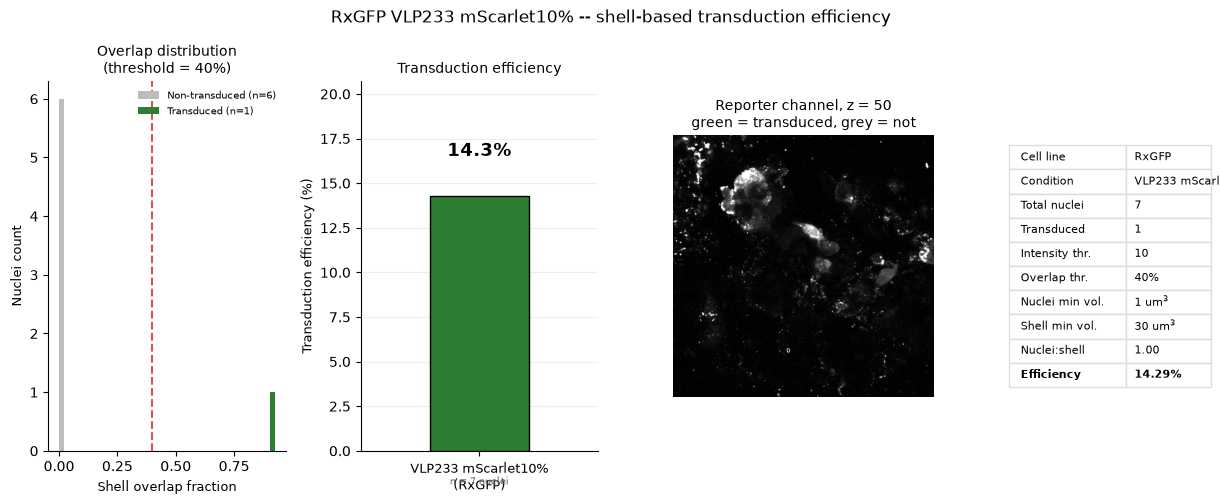

Saved summary CSV     : \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_transduction_summary_int10_ov0.4.csv
Saved per-nucleus CSV : \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_per_nucleus_int10_ov0.4.csv

file                            20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01
cell_line                                                                                     RxGFP
condition                                                                        VLP233 mScarlet10%
total_nuclei                                                                                      7
transduced_nuclei                                                                                 1
transduc

In [ ]:
FG, POS_C, NEG_C, THRESH_C = "#000000", "#2E7D32", "#BDBDBD", "#D9534F"

fig = plt.figure(figsize=(15, 4.8), facecolor="white")
gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1.1, 0.85], wspace=0.32)

# ---------- Panel 1: overlap distribution, split by call ----------
ax = fig.add_subplot(gs[0])
bins = np.linspace(0, shell_df["overlap_fraction"].max() + 1e-6, 45)
ax.hist(shell_df.loc[~shell_df["transduced"], "overlap_fraction"], bins=bins,
        color=NEG_C, edgecolor="none", label=f"Non-transduced (n={n_total-n_transduced})")
ax.hist(shell_df.loc[shell_df["transduced"], "overlap_fraction"], bins=bins,
        color=POS_C, edgecolor="none", label=f"Transduced (n={n_transduced})")
ax.axvline(OVERLAP_THRESHOLD, color=THRESH_C, linestyle="--", linewidth=1.5)
ax.set_xlabel("Shell overlap fraction", fontsize=9)
ax.set_ylabel("Nuclei count", fontsize=9)
ax.set_title(f"Overlap distribution\n(threshold = {OVERLAP_THRESHOLD:.0%})", fontsize=10)
ax.legend(frameon=False, fontsize=7.5)
ax.spines[["top", "right"]].set_visible(False)

# ---------- Panel 2: efficiency bar ----------
ax = fig.add_subplot(gs[1])
ax.bar([0], [efficiency], width=0.5, color=POS_C, edgecolor="black", linewidth=1)
ax.text(0, efficiency + 2, f"{efficiency:.1f}%", ha="center", va="bottom",
        fontsize=13, fontweight="bold")
ax.set_xticks([0]); ax.set_xticklabels([f"{condition_label}\n({cell_line})"], fontsize=9)
ax.set_ylabel("Transduction efficiency (%)", fontsize=9)
ax.set_ylim(0, min(100, max(efficiency * 1.45, 12)))
ax.set_xlim(-0.6, 0.6)
ax.set_title("Transduction efficiency", fontsize=10)
ax.text(0, -efficiency * 0.10, f"n = {n_total} nuclei", ha="center", va="top",
        fontsize=7.5, color="#666666")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
ax.set_axisbelow(True)

# ---------- Panel 3: mid-plane overlay ----------
ax = fig.add_subplot(gs[2])
plane_bg = rep_processed[mid]
ax.imshow(plane_bg, cmap="gray",
          vmin=np.percentile(plane_bg, 1), vmax=np.percentile(plane_bg, 99.5))

plane_shells = shells_filtered[mid]
pos_labels = shell_df.loc[shell_df["transduced"], "nucleus_label"].values
neg_labels = shell_df.loc[~shell_df["transduced"], "nucleus_label"].values

neg_plane = np.isin(plane_shells, neg_labels).astype(float)
pos_plane = np.isin(plane_shells, pos_labels).astype(float)
if neg_plane.any():
    ax.contour(neg_plane, levels=[0.5], colors=NEG_C, linewidths=0.6)
if pos_plane.any():
    ax.contour(pos_plane, levels=[0.5], colors=POS_C, linewidths=0.8)

ax.set_title(f"Reporter channel, z = {mid}\ngreen = transduced, grey = not", fontsize=10)
ax.axis("off")

# ---------- Panel 4: parameter table ----------
ax = fig.add_subplot(gs[3])
ax.axis("off")
rows = [
    ["Cell line",           cell_line],
    ["Condition",           condition_label],
    ["Total nuclei",        f"{n_total}"],
    ["Transduced",          f"{n_transduced}"],
    ["Intensity thr.",      f"{REPORTER_INTENSITY_THRESHOLD:g}"],
    ["Overlap thr.",        f"{OVERLAP_THRESHOLD:.0%}"],
    ["Nuclei min vol.",     f"{NUCLEI_MIN_VOL_UM3:g} um$^3$"],
    ["Shell min vol.",      f"{SHELL_MIN_VOL_UM3:g} um$^3$"],
    ["Nuclei:shell",        f"{ratio:.2f}"],
    ["Efficiency",          f"{efficiency:.2f}%"],
]
tbl = ax.table(cellText=rows, cellLoc="left", loc="center", colWidths=[0.58, 0.42])
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.45)
for key, cell in tbl.get_celld().items():
    cell.set_edgecolor("#DDDDDD")
    if key[0] == len(rows) - 1:
        cell.set_text_props(weight="bold")

fig.suptitle(f"{cell_line} {condition_label} -- shell-based transduction efficiency",
             fontsize=12.5, y=1.03)
plt.tight_layout()

thr_tag = f"int{REPORTER_INTENSITY_THRESHOLD:g}_ov{OVERLAP_THRESHOLD:g}"
png_path = os.path.join(output_dir, f"{base_name}_transduction_efficiency_{thr_tag}.png")
svg_path = os.path.join(output_dir, f"{base_name}_transduction_efficiency_{thr_tag}.svg")

fig.savefig(png_path, format="png", dpi=300, facecolor="white", edgecolor="none", bbox_inches="tight")
fig.savefig(svg_path, format="svg", facecolor="white", edgecolor="none", bbox_inches="tight")

print(f"Saved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")

plt.show()

# ---------- summary + per-nucleus CSVs ----------
summary = pd.DataFrame([{
    "file": base_name,
    "cell_line": cell_line,
    "condition": condition_label,
    "total_nuclei": n_total,
    "transduced_nuclei": n_transduced,
    "transduction_efficiency_pct": round(efficiency, 2),
    "reporter_intensity_threshold": REPORTER_INTENSITY_THRESHOLD,
    "overlap_threshold": OVERLAP_THRESHOLD,
    "nuclei_min_volume_um3": NUCLEI_MIN_VOL_UM3,
    "shell_min_volume_um3": SHELL_MIN_VOL_UM3,
    "dilation_px": DILATION_PIXELS,
    "nuclei_to_shell_ratio": round(ratio, 3),
    "transduced_volume_fraction_pct": round(100 * transduced_mask.mean(), 3),
    "bin_percent": bin_percent,
    "denoise_sigma_px": denoise_sigma_px,
}])
summary_path = os.path.join(output_dir, f"{base_name}_transduction_summary_{thr_tag}.csv")
summary.to_csv(summary_path, index=False)

per_nucleus_path = os.path.join(output_dir, f"{base_name}_per_nucleus_{thr_tag}.csv")
shell_df.to_csv(per_nucleus_path, index=False)

print(f"Saved summary CSV     : {summary_path}")
print(f"Saved per-nucleus CSV : {per_nucleus_path}")
print()
print(summary.T.to_string(header=False))

**3D view of transduction calls.** Ellipsoid approximation of each nucleus (fitted from its voxel covariance), colored by whether it was called transduced — a final visual gut-check on the headline number.

Fitted 7 ellipsoids | transduced 1 (14.3%)
Saved PNG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_ellipsoids_transduced.png
Saved SVG: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26a\experiments\LSM\20260325_DIV37_VLP\20260325_E14_DIV37_VLP233mScarle10percent_Nucspot488_SirActin650-01_ellipsoids_transduced.svg


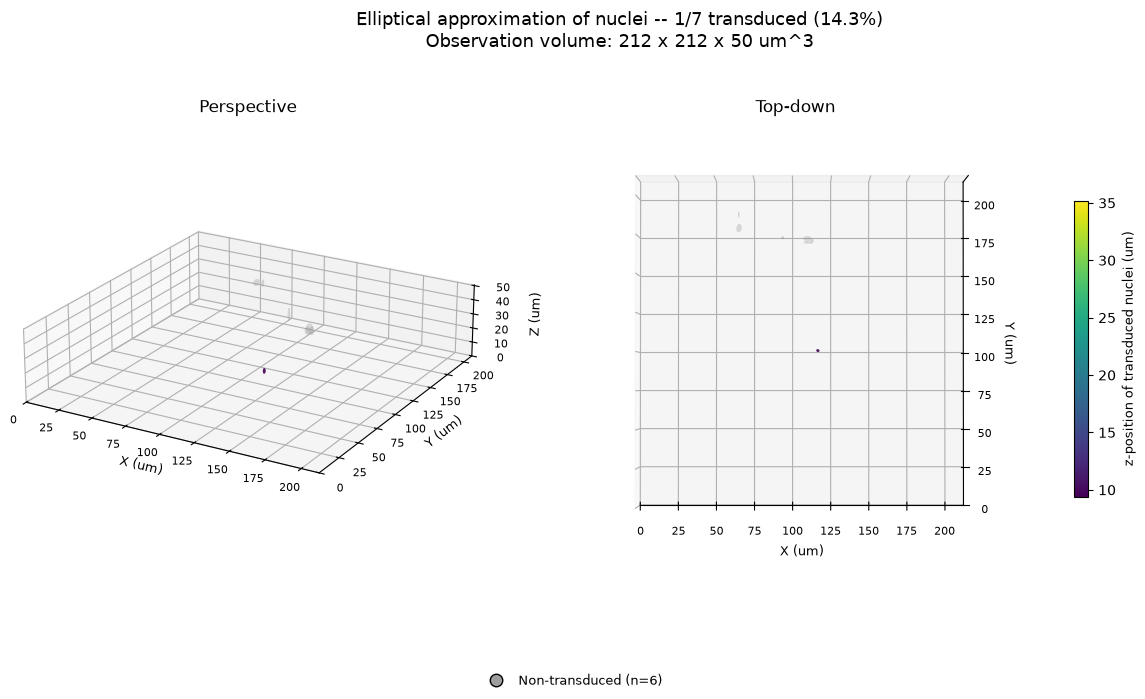

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D
import matplotlib as mpl

# =========================================================
# ELLIPSOID FIT, COLOURED BY TRANSDUCTION CALL
# -----------------------------------------------------------------
# Covariance of each nucleus's voxel coordinates (in physical um)
# gives the principal axes (eigenvectors) and their extent
# (eigenvalues); semi-axis = 2*sqrt(eigenvalue) is the "equivalent
# ellipsoid" with the same second moment as the original object.
# Reuses nuclei_size_filtered and shell_df -- no CSV reload needed.
# =========================================================
COLOR_MODE = "highlight"    # "highlight": transduced coloured by z-position, non-transduced faint grey
                            # "binary":    transduced solid green, non-transduced grey
ellipsoid_resolution = 8
NON_TRANSDUCED_ALPHA = 0.18
TRANSDUCED_ALPHA = 0.95

transduced_set = set(shell_df.loc[shell_df["transduced"], "nucleus_label"].astype(int))
shell_labels_set = set(shell_df["nucleus_label"].astype(int))

voxel_size = np.array([z_step_um, xy_pixel_um_eff, xy_pixel_um_eff])
ellipsoids = []
objects = ndimage.find_objects(nuclei_size_filtered)

for lab in nuclei_kept:
    if int(lab) not in shell_labels_set:
        continue
    sl = objects[lab - 1]
    if sl is None:
        continue
    sub = nuclei_size_filtered[sl] == lab
    coords = np.argwhere(sub).astype(np.float64)
    if len(coords) < 8:
        continue
    offset = np.array([s.start for s in sl], dtype=np.float64)
    coords_um = (coords + offset) * voxel_size

    centroid = coords_um.mean(axis=0)
    cov = np.cov((coords_um - centroid).T)
    evals, evecs = np.linalg.eigh(cov)
    evals = np.clip(evals, 1e-9, None)

    ellipsoids.append({
        "label": int(lab),
        "centroid": centroid,
        "semi_axes": 2.0 * np.sqrt(evals),
        "rotation": evecs,
        "transduced": int(lab) in transduced_set,
    })

n_trans = sum(e["transduced"] for e in ellipsoids)
n_ell_total = len(ellipsoids)
print(f"Fitted {n_ell_total} ellipsoids | transduced {n_trans} ({100*n_trans/n_ell_total:.1f}%)")

u = np.linspace(0, 2 * np.pi, ellipsoid_resolution * 2)
v = np.linspace(0, np.pi, ellipsoid_resolution)
uu, vv = np.meshgrid(u, v)
unit = np.stack([np.cos(uu) * np.sin(vv), np.sin(uu) * np.sin(vv),
                 np.cos(vv) * np.ones_like(uu)], axis=-1)


def ellipsoid_faces(e):
    pts = unit * e["semi_axes"]
    pts = pts @ e["rotation"].T + e["centroid"]
    pts = pts[..., ::-1]                      # (z,y,x) -> (x,y,z)
    faces = []
    for i in range(pts.shape[0] - 1):
        for j in range(pts.shape[1] - 1):
            faces.append([pts[i, j], pts[i, j + 1], pts[i + 1, j + 1], pts[i + 1, j]])
    return faces


z_pos = np.array([e["centroid"][0] for e in ellipsoids])
norm = mpl.colors.Normalize(vmin=z_pos.min(), vmax=z_pos.max())
cmap = plt.cm.viridis
GREY = (0.62, 0.62, 0.62)
GREEN = (0.18, 0.49, 0.20)


def color_for(e):
    if COLOR_MODE == "highlight":
        return cmap(norm(e["centroid"][0])) if e["transduced"] else GREY
    return GREEN if e["transduced"] else GREY


fig = plt.figure(figsize=(16, 7), facecolor="white")
nz3, ny3, nx3 = nuclei_size_filtered.shape

for idx, (elev, azim, title) in enumerate([(22, -60, "Perspective"), (89, -90, "Top-down")]):
    ax = fig.add_subplot(1, 2, idx + 1, projection="3d")

    # non-transduced drawn first so transduced render on top
    for group, alpha in [(False, NON_TRANSDUCED_ALPHA), (True, TRANSDUCED_ALPHA)]:
        faces, face_colors = [], []
        for e in ellipsoids:
            if e["transduced"] != group:
                continue
            f = ellipsoid_faces(e)
            faces.extend(f)
            face_colors.extend([color_for(e)] * len(f))
        if faces:
            ax.add_collection3d(Poly3DCollection(
                faces, facecolors=face_colors, edgecolors="none",
                alpha=alpha, linewidths=0))

    ax.set_xlim(0, nx3 * xy_pixel_um_eff)
    ax.set_ylim(0, ny3 * xy_pixel_um_eff)
    ax.set_zlim(0, nz3 * z_step_um)
    ax.set_box_aspect((nx3 * xy_pixel_um_eff, ny3 * xy_pixel_um_eff, nz3 * z_step_um))
    ax.set_xlabel("X (um)", fontsize=9)
    ax.set_ylabel("Y (um)", fontsize=9)
    ax.set_zlabel("Z (um)", fontsize=9)
    ax.set_title(title, fontsize=12)
    ax.view_init(elev=elev, azim=azim)
    ax.tick_params(labelsize=8)
    if elev > 80:
        ax.set_zticks([])
        ax.set_zlabel("")

if COLOR_MODE == "highlight":
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=fig.axes, shrink=0.55, pad=0.04)
    cbar.set_label("z-position of transduced nuclei (um)", fontsize=9)
    handles = [Line2D([0], [0], marker="o", color="none", markerfacecolor=GREY,
                      markersize=9, label=f"Non-transduced (n={n_ell_total-n_trans})")]
else:
    handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=GREEN,
               markersize=9, label=f"Transduced (n={n_trans})"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=GREY,
               markersize=9, label=f"Non-transduced (n={n_ell_total-n_trans})"),
    ]

fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, fontsize=9)

vol_str = f"{nx3*xy_pixel_um_eff:.0f} x {ny3*xy_pixel_um_eff:.0f} x {nz3*z_step_um:.0f} um^3"
fig.suptitle(f"Elliptical approximation of nuclei -- {n_trans}/{n_ell_total} transduced "
             f"({100*n_trans/n_ell_total:.1f}%)\nObservation volume: {vol_str}", fontsize=13)

png_path = os.path.join(output_dir, f"{base_name}_ellipsoids_transduced.png")
svg_path = os.path.join(output_dir, f"{base_name}_ellipsoids_transduced.svg")
fig.savefig(png_path, dpi=250, facecolor="white", bbox_inches="tight")
fig.savefig(svg_path, format="svg", facecolor="white", bbox_inches="tight")
print(f"Saved PNG: {png_path}")
print(f"Saved SVG: {svg_path}")
plt.show()